# Envrionment

In [1]:
import os
from pathlib import Path
os.chdir('/Users/burkelawlor/Repos/hci-irae')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import spatialdata as sd
import scanpy as sc
import squidpy as sq
import anndata as ad
from spatialdata_io import xenium

from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

from utils.processing import propogate_subset_labels, get_ranked_genes_by_group
from utils.plotting import feature_plots_from_marker_genes, spatial_plot_cell_types_individual, spatial_plot_cell_types_layered, plot_proportions_bar

# Load data

In [2]:
adata_rmc = ad.read_h5ad("./data/adata/rmc_annotated_4_cutaneous.h5ad")

/Users/burkelawlor/Repos/hci-irae/.env/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


# Checking relative expression of JAK/STATs

In [3]:
adata_rmc

AnnData object with n_obs × n_vars = 386902 × 5001
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'region', 'z_level', 'cell_labels', 'centroidX', 'centroidY', 'cell_id_unique', 'sample_name', 'sample_set', 'batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'nucleus_ratio', 'n_genes', 'log1p_total_counts_outlier', 'log1p_n_genes_by_counts_outlier', 'nucleus_ratio_outlier', 'outlier_mad', 'outlier_min_counts_50', 'outlier_min_counts_100', 'outlier_abs', 'n_counts', 'nucleus_ratio_1', 'leiden_25', 'leiden_20', 'leiden_10', 'leiden_03', 'cell_type_general', 'cell_type_detailed', 'ct_immune', 'leiden_endothelial', 'ct_endothelial',

# Differential expression analysis

In [ ]:
adata_lymphoid = adata_immune[adata_immune.obs['sample_name'].isin(['EPD1', 'EPD2', 'EPD3', 'EPD5'])].copy()

In [ ]:
counts = adata_lymphoid.layers['raw_counts'].copy().toarray()
genes = adata_lymphoid.var_names.to_list()

In [ ]:
sample_col = 'sample_name'
celltype_col = 'cell_type_immune_detailed'
condition_col = 'lymphoid_annotation'

obs = adata_lymphoid.obs[[sample_col, celltype_col, condition_col]].copy()
obs["__group_key__"] = (obs[sample_col].astype(str) + "||" + obs[celltype_col].astype(str) + "||" + obs[condition_col].astype(str))

# Count cells per group and filter tiny groups
min_cells_per_group = 20
group_sizes = obs["__group_key__"].value_counts()
keep_groups = group_sizes[group_sizes >= min_cells_per_group].index
keep_mask = obs["__group_key__"].isin(keep_groups).to_numpy()

obs_f = obs.loc[keep_mask].copy()
counts_f = counts[keep_mask, :]


In [ ]:
group_keys = obs_f["__group_key__"].unique()
key_to_row = {k: i for i, k in enumerate(group_keys)}
row_ids = obs_f["__group_key__"].map(key_to_row).to_numpy()

n_groups = len(group_keys)
n_cells = counts_f.shape[0]

# Sum counts across cells for each group
pb = np.zeros((n_groups, counts_f.shape[1]), dtype=counts_f.dtype)
for i in range(n_cells):
    pb[row_ids[i], :] += counts_f[i, :]

# Make dataframes for metadata and counts
pb_meta = pd.DataFrame([k.split("||") for k in group_keys], columns=[sample_col, celltype_col, condition_col], index=group_keys, dtype='category')
pb_counts = pd.DataFrame(pb, index=group_keys, columns=genes).astype(int)

# # Filter genes with low counts
# min_total_counts_per_genes = 10
# pb_counts = pb_counts.loc[:, pb_counts.sum(axis=0) >= min_total_counts_per_genes].copy()

In [ ]:
results = {}
for ct, meta_ct in pb_meta.groupby(celltype_col):
    print(ct)
    idx = meta_ct.index
    counts_ct = pb_counts.loc[idx]
    meta_ct = meta_ct.copy()

    # Check some conditions
    if len(meta_ct) < 4: # Requires at least 4 samples
        continue
    if meta_ct[condition_col].nunique() < 2: # Requires both conditions
        continue
    if (meta_ct.groupby([condition_col]).size() < 2).any(): # Each condition has at least 2 samples
        continue

    try:
        # Run DESeq2
        dds = DeseqDataSet(counts=counts_ct, metadata=meta_ct, design=f'~ {sample_col} + {condition_col}')
        dds.deseq2()

        stats_res = DeseqStats(dds, contrast=(condition_col, 'lymphoid', 'not lymphoid'))
        stats_res.summary()
        result = stats_res.results_df.copy()

        result["gene"] = result.index
        result = result.sort_values("padj")

        results[ct] = result
    except Exception as e:
        print(f"[WARN] Skipping cell type '{ct}' due to error: {e}")
    
    print('#'*100)

B cell
Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 0.11 seconds.

Fitting dispersion trend curve...
... done in 0.03 seconds.

/Users/burkelawlor/Repos/hci/.env/lib/python3.12/site-packages/pydeseq2/dds.py:548: UserWarning: As the residual degrees of freedom is less than 3, the distribution of log dispersions is especially asymmetric and likely to be poorly estimated by the MAD.
  self.fit_dispersion_prior()
Fitting MAP dispersions...
... done in 0.15 seconds.

Fitting LFCs...
... done in 0.17 seconds.

Calculating cook's distance...
... done in 0.00 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 0.11 seconds.

Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...


Log2 fold change & Wald test p-value: lymphoid_annotation lymphoid vs not lymphoid
          baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
A2ML1     0.034970       -0.402284  5.374761 -0.074847  0.940337  0.999925
AAMP     12.181273        0.295418  0.579167  0.510074  0.609999  0.999925
AAR2      3.911018        0.212934  0.958709  0.222105  0.824232  0.999925
AARSD1    5.806086        0.392006  0.785654  0.498955  0.617811  0.999925
ABAT      3.973224       -0.650910  0.920790 -0.706904  0.479626  0.999925
...            ...             ...       ...       ...       ...       ...
ZSCAN26   7.109353        0.862381  0.700263  1.231509  0.218132  0.999925
ZSWIM6    1.816823       -0.610836  1.392342 -0.438711  0.660871  0.999925
ZUP1      5.954652        0.206777  0.743175  0.278234  0.780833  0.999925
ZYG11B    4.214566       -0.525725  0.874839 -0.600939  0.547881  0.999925
ZYX      20.961690        0.395960  0.475796  0.832206  0.405293  0.999925

[5001 rows x 6 c

... done in 0.15 seconds.

Fitting dispersion trend curve...
... done in 0.04 seconds.

Fitting MAP dispersions...
... done in 0.18 seconds.

Fitting LFCs...
... done in 0.19 seconds.

Calculating cook's distance...
... done in 0.00 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 0.12 seconds.

Fitting size factors...
... done in 0.00 seconds.



Log2 fold change & Wald test p-value: lymphoid_annotation lymphoid vs not lymphoid
          baseMean  log2FoldChange     lfcSE      stat    pvalue     padj
A2ML1     0.735531       -1.134343  1.210838 -0.936825  0.348849      NaN
AAMP     35.862608        0.057925  0.214142  0.270498  0.786777  0.99721
AAR2      9.270578        0.258510  0.384149  0.672943  0.500984  0.99721
AARSD1   14.573679       -0.067848  0.307746 -0.220469  0.825506  0.99721
ABAT      7.854142       -0.168492  0.394260 -0.427363  0.669115  0.99721
...            ...             ...       ...       ...       ...      ...
ZSCAN26  13.022219       -0.072208  0.352291 -0.204966  0.837599  0.99721
ZSWIM6    3.740474        0.376378  0.681726  0.552096  0.580883  0.99721
ZUP1     12.213061       -0.092863  0.339379 -0.273625  0.784373  0.99721
ZYG11B   12.258388       -0.273899  0.321158 -0.852848  0.393743  0.99721
ZYX      91.468621        0.008509  0.153239  0.055530  0.955717  0.99721

[5001 rows x 6 columns]
####

...

Fitting dispersions...
... done in 0.14 seconds.

Fitting dispersion trend curve...
... done in 0.04 seconds.

Fitting MAP dispersions...
... done in 0.17 seconds.

Fitting LFCs...
... done in 0.19 seconds.

Calculating cook's distance...
... done in 0.00 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 0.12 seconds.

Fitting size factors...
... done in 0.00 seconds.



Log2 fold change & Wald test p-value: lymphoid_annotation lymphoid vs not lymphoid
          baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
A2ML1     0.305362        0.992463  3.238482  0.306459  0.759255       NaN
AAMP      8.826447        0.321828  0.369612  0.870717  0.383909  0.993421
AAR2      3.046273       -0.590257  0.598826 -0.985689  0.324286  0.993421
AARSD1    3.849007        0.130260  0.602905  0.216055  0.828945  0.993421
ABAT      4.463973        0.420161  0.467842  0.898083  0.369141  0.993421
...            ...             ...       ...       ...       ...       ...
ZSCAN26   3.851322        0.389240  0.505712  0.769688  0.441485  0.993421
ZSWIM6    0.893824       -0.623606  1.205860 -0.517147  0.605054       NaN
ZUP1      4.612437       -0.307929  0.488937 -0.629793  0.528830  0.993421
ZYG11B    4.290700       -0.791943  0.641298 -1.234906  0.216866  0.993421
ZYX      41.861048       -0.127540  0.170998 -0.745856  0.455754  0.993421

[5001 rows x 6 c

Fitting dispersions...
... done in 0.12 seconds.

Fitting dispersion trend curve...
... done in 0.03 seconds.

Fitting MAP dispersions...
... done in 0.17 seconds.

Fitting LFCs...
... done in 0.19 seconds.

Calculating cook's distance...
... done in 0.00 seconds.

Replacing 0 outlier genes.



Log2 fold change & Wald test p-value: lymphoid_annotation lymphoid vs not lymphoid
          baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
A2ML1     0.128796       -0.217235  3.874473 -0.056068  0.955287  0.999704
AAMP      5.380534        0.433428  0.535407  0.809530  0.418210  0.999704
AAR2      2.075984        0.870961  0.871989  0.998822  0.317881  0.999704
AARSD1    2.136562        0.100775  0.787487  0.127970  0.898173  0.999704
ABAT      0.972173       -0.144297  1.145925 -0.125922  0.899794  0.999704
...            ...             ...       ...       ...       ...       ...
ZSCAN26   3.441504        0.741621  0.647956  1.144555  0.252393  0.999704
ZSWIM6    0.635530       -2.307762  1.680128 -1.373563  0.169577  0.999704
ZUP1      3.101041        0.029445  0.651222  0.045216  0.963935  0.999704
ZYG11B    1.552397        0.813968  1.168482  0.696603  0.486051  0.999704
ZYX      19.340047       -0.377065  0.281744 -1.338325  0.180791  0.999704

[5001 rows x 6 c

Running Wald tests...
... done in 0.11 seconds.



In [ ]:
from adjustText import adjust_text

def volcano_plot(results_df, lfc_col="log2FoldChange", pval_col="padj", lfc_thresh=0.25, pval_thresh=0.05, title=None, label_top_genes=10):
    """
    Create a volcano plot from a DESeq2 results DataFrame.
    """

    # Drop rows with missing values
    df = results_df[[lfc_col, pval_col]].dropna()
    x = df[lfc_col]
    y = -np.log10(df[pval_col])

    up = (df[lfc_col] > lfc_thresh) & (df[pval_col] < pval_thresh)
    down = (df[lfc_col] < -lfc_thresh) & (df[pval_col] < pval_thresh)
    not_sig = ~(up | down)

    plt.figure(figsize=(6, 6))
    plt.scatter(df.loc[not_sig, lfc_col], -np.log10(df.loc[not_sig, pval_col]), s=10, alpha=0.5, label="Not significant")
    plt.scatter(df.loc[up, lfc_col], -np.log10(df.loc[up, pval_col]), s=15, alpha=0.7, label="Upregulated", color='blue')
    plt.scatter(df.loc[down, lfc_col], -np.log10(df.loc[down, pval_col]), s=15, alpha=0.7, label="Downregulated", color='red')

    # Label top genes
    texts=[]
    for i, (g,r) in enumerate(df[up].iterrows()):
        texts.append(plt.text(x=r[lfc_col],y=-np.log10(r[pval_col]),s=g))
        if i == label_top_genes-1:
            break
    for i, (g,r) in enumerate(df[down].iterrows()):
        texts.append(plt.text(x=r[lfc_col],y=-np.log10(r[pval_col]),s=g))
        if i == label_top_genes-1:
            break
    adjust_text(texts, arrowprops=dict(arrowstyle="-", color='black', lw=0.5))
    
    
    # Threshold lines
    plt.axvline(lfc_thresh, linestyle="--")
    plt.axvline(-lfc_thresh, linestyle="--")
    plt.axhline(-np.log10(pval_thresh), linestyle="--")
    
    plt.xlabel("log2 Fold Change")
    plt.ylabel("-log10 adjusted p-value")

    if title:
        plt.title(title)

    plt.legend()

    plt.tight_layout()
    plt.show()

In [ ]:
for ct, meta_ct in pb_meta.groupby(celltype_col):
    print(ct)

B cell
CD4+ T cells
CD8+ T cells
CLEC10A+ DCs
CLEC9A+ DCs
LAMP3+ DCs
Macrophage
Neutrophil
Other lymphocytes
Plasmacytoid DC
Tregs
Unknown myeloid?
gamma delta T cells


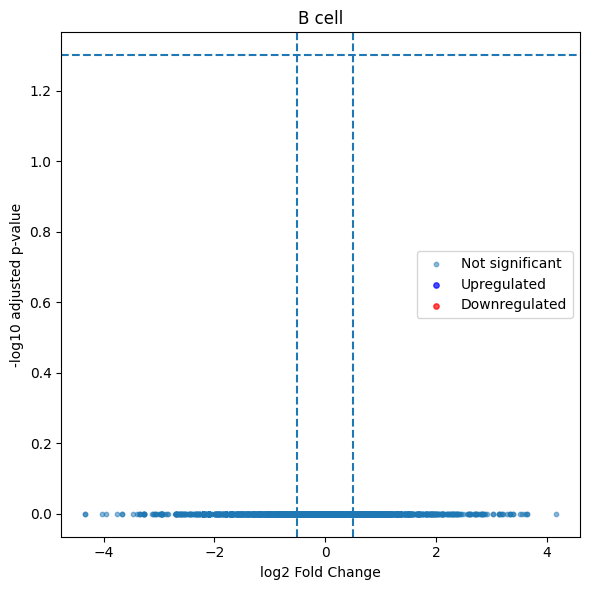

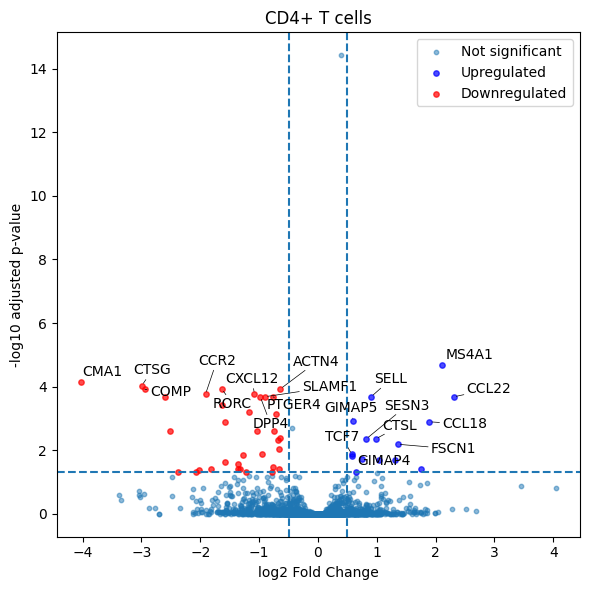

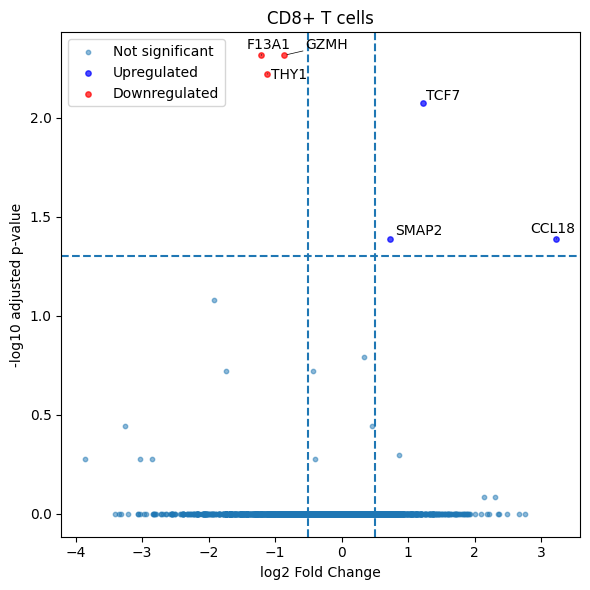

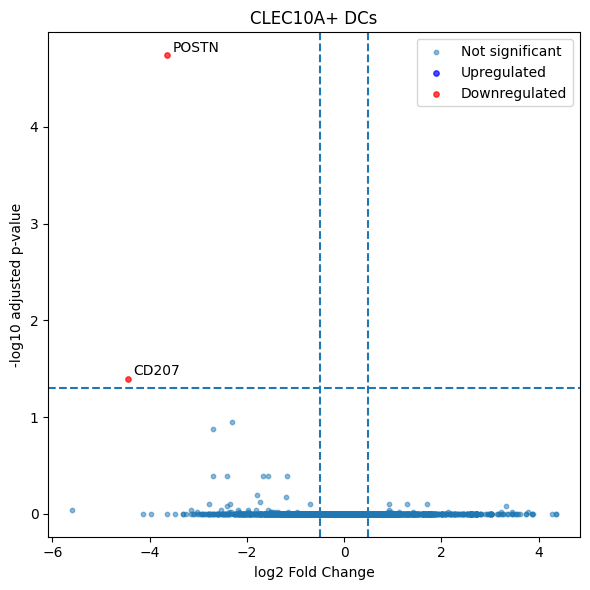

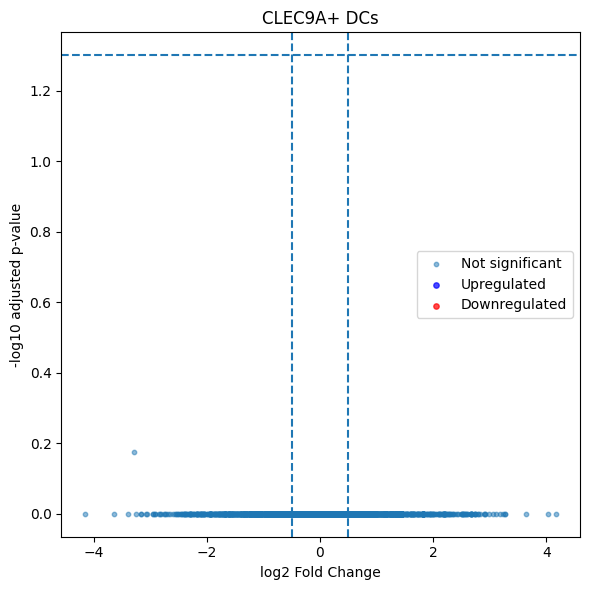

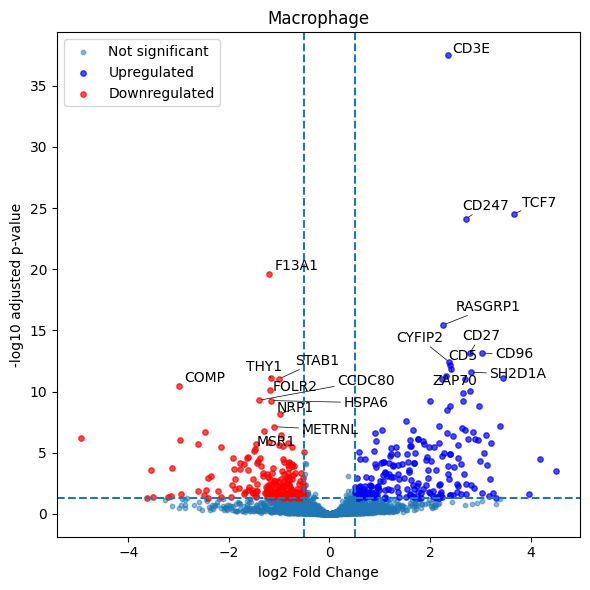

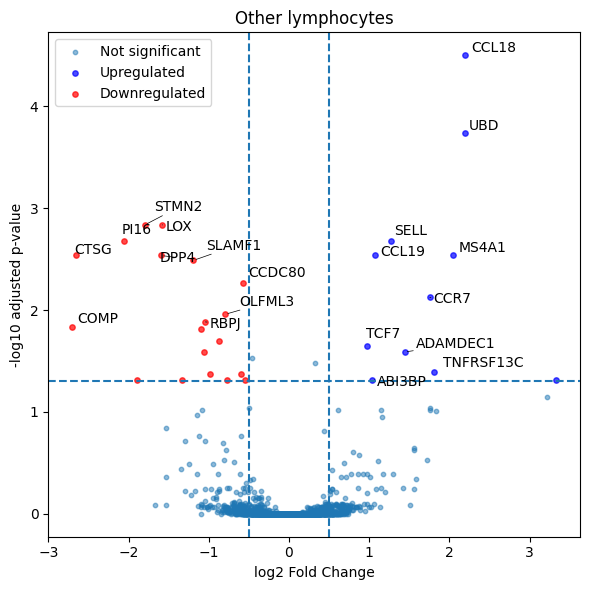

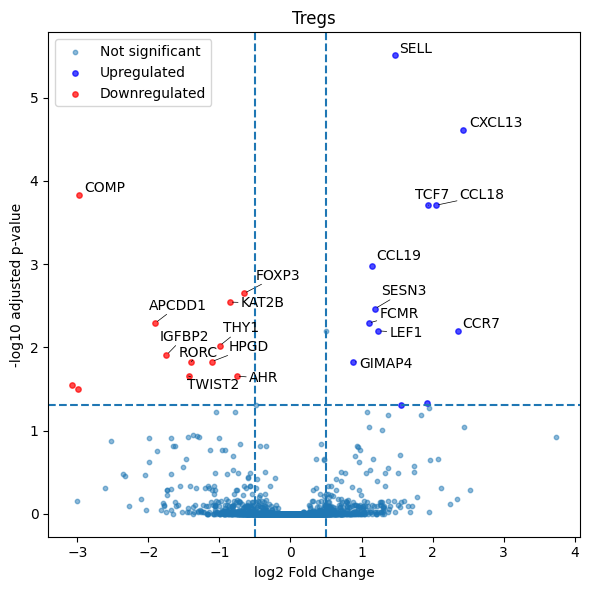

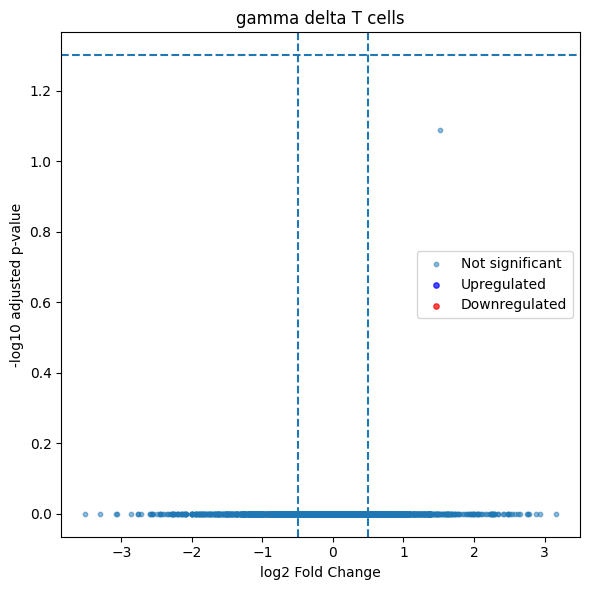

In [ ]:
for ct, result_df in results.items():
    volcano_plot(result_df, lfc_thresh=0.5, pval_thresh=0.05, title=ct)